# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Capstone Project | Hotel Reservation Cancellations</p>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:120%; text-align:left">

<h3 align="left"><font color=red>Problem:</font></h3>

A prominent hotel chain, aims to enhance their understanding of reservation cancellation patterns and improve their revenue management strategies. They want to leverage machine learning to predict hotel reservation cancellations based on various booking and guest-related factors. By developing accurate prediction models, the hotel chain seeks to optimize resource allocation, implement dynamic pricing strategies, and potentially devise targeted retention initiatives to minimize revenue loss from cancellations.

<a id="import"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 1 | Import Libraries</p>

In [1]:
# IMPORT LIBRARIES 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',None)
plt.style.use('ggplot')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# LOAD DATASET

df = pd.read_csv(r"C:\Users\sneha\Downloads\ZUARI_INDUSTRIES_NEW\New_hotel_BIA\Hotel Reservations.csv")

In [3]:
print("DAtaset Loaded Successfully")

DAtaset Loaded Successfully


<a id="read"></a>
# <p style="background-color:red ; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 2 | Read Dataset</p>

In [4]:
# UNDERSTAND DATASET

df.head()


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [5]:
df.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67,0,Not_Canceled


In [6]:
df.shape

(36275, 19)

In [7]:
# DATASET INFORMATION

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [8]:
# STATISTICAL SUMMARY

df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [9]:
# CHECK MISSING VALUES 
df.isnull().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [10]:
# Duplicate Values

df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
36270    False
36271    False
36272    False
36273    False
36274    False
Length: 36275, dtype: bool

<a id="overview"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 3 | Dataset Overview</p>

In [11]:
# Cloumns Names 

df.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='object')

In [12]:
# TARGET VARIABLE CHECK 

df['booking_status'].value_counts()

booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64

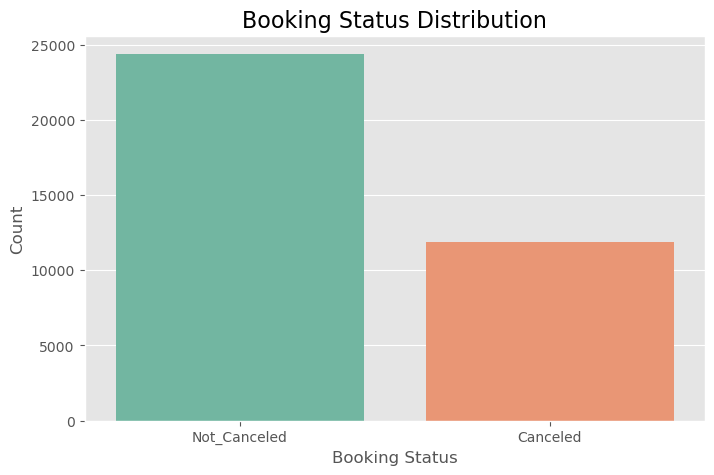

In [13]:
# BOOKING STATUS VISUALIZATION

plt.figure(figsize=(8,5))

sns.countplot(
    x = 'booking_status',
    data = df,
    palette = 'Set2'
)

plt.title("Booking Status Distribution",fontsize=16)
plt.xlabel('Booking Status')
plt.ylabel('Count')

plt.show()

In [14]:
# ==============================
# CREATE BACKUP COPY
# ==============================

df1 = df.copy()

In [15]:
# CHECK MISSING VALUES PROPERLY

missing_values = df1.isnull().sum()

missing_values

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [16]:
# Better missing value table

missing_percentage = (df1.isnull().sum()/len(df1))*100

missing_table = pd.DataFrame({
    'Missing Values':df1.isnull().sum(),
    'Percentage':missing_percentage
})

missing_table

,Missing Values,Percentage
Booking_ID,0,0.0
no_of_adults,0,0.0
no_of_children,0,0.0
no_of_weekend_nights,0,0.0
no_of_week_nights,0,0.0
type_of_meal_plan,0,0.0
required_car_parking_space,0,0.0
room_type_reserved,0,0.0
lead_time,0,0.0
arrival_year,0,0.0


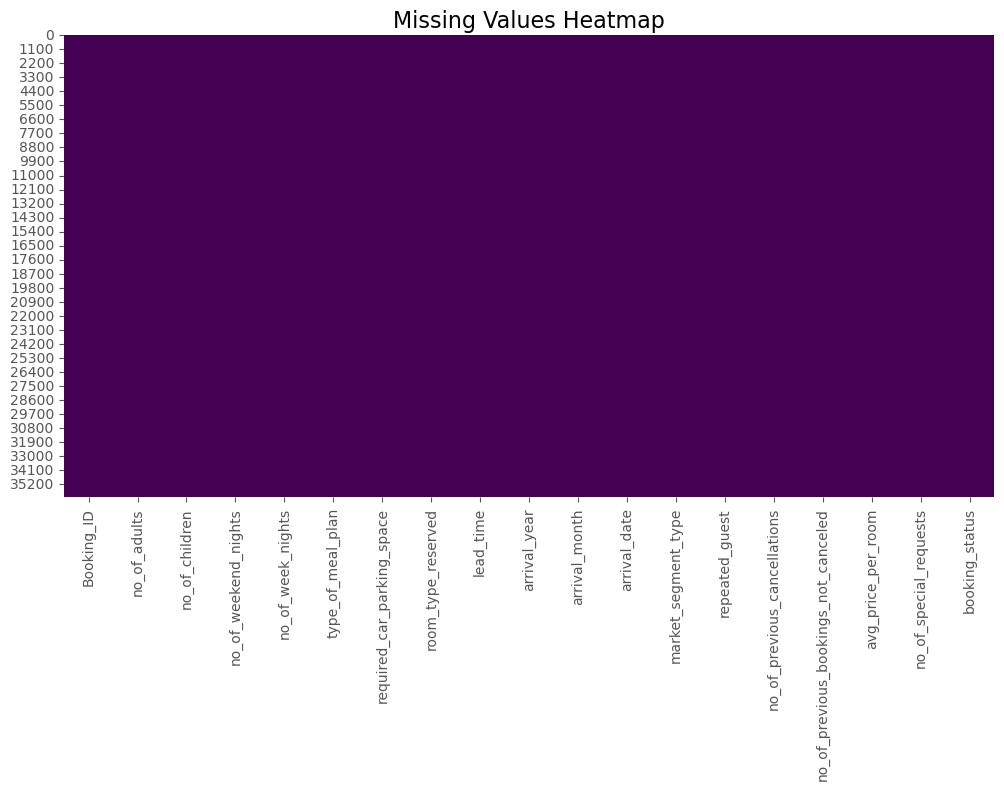

In [17]:
# ==============================
# MISSING VALUE HEATMAP
# ==============================

plt.figure(figsize=(12,6))

sns.heatmap(
    df1.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title('Missing Values Heatmap', fontsize=16)

plt.show()

In [18]:
# Fill numerical missing values with median

num_cols = df1.select_dtypes(include=np.number).columns

for col in num_cols:
    df1[col].fillna(df1[col].median(), inplace=True)

In [19]:
# Fill categorical missing values with mode

cat_cols = df1.select_dtypes(include='object').columns

for col in cat_cols:
    df1[col].fillna(df1[col].mode()[0], inplace=True)

In [20]:
# ==============================
# DUPLICATE VALUES
# ==============================

df1.duplicated().sum()

np.int64(0)

In [21]:
# Remove Duplicate Rows

df1.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


In [22]:
df1.shape

(36275, 19)

In [23]:
# ==============================
# DATA TYPES
# ==============================

df1.dtypes

Booking_ID                               object
no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
room_type_reserved                       object
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
market_segment_type                      object
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                           object
dtype: object

In [24]:
# ==============================
# UNIQUE VALUES
# ==============================

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df1[col].unique())


Column: Booking_ID
['INN00001' 'INN00002' 'INN00003' ... 'INN36273' 'INN36274' 'INN36275']

Column: type_of_meal_plan
['Meal Plan 1' 'Not Selected' 'Meal Plan 2' 'Meal Plan 3']

Column: room_type_reserved
['Room_Type 1' 'Room_Type 4' 'Room_Type 2' 'Room_Type 6' 'Room_Type 5'
 'Room_Type 7' 'Room_Type 3']

Column: market_segment_type
['Offline' 'Online' 'Corporate' 'Aviation' 'Complementary']

Column: booking_status
['Not_Canceled' 'Canceled']


<a id="eda"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 4 | EDA</p>

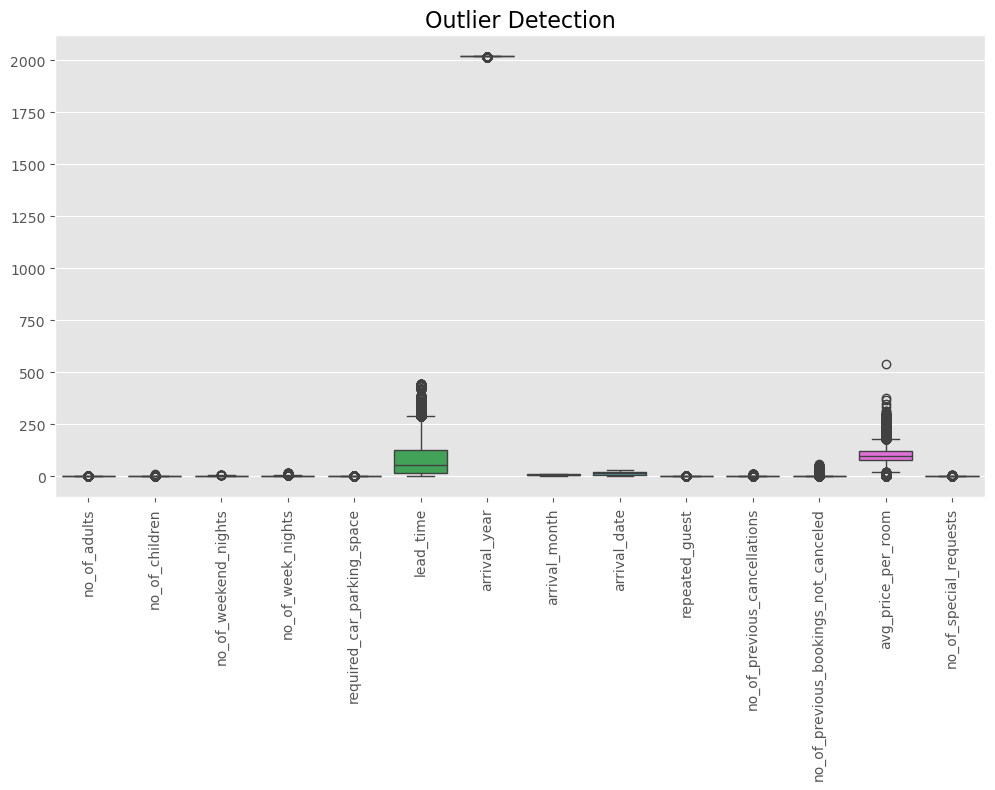

In [25]:
# ==============================
# BOXPLOT FOR OUTLIERS
# ==============================

plt.figure(figsize=(12,6))

sns.boxplot(data=df1.select_dtypes(include=np.number))

plt.xticks(rotation=90)

plt.title('Outlier Detection', fontsize=16)

plt.show()

In [26]:
# Final Missing Value Check

df1.isnull().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [27]:
# Save Clean Dataset

df1.to_csv(r"C:\Users\sneha\Downloads\ZUARI_INDUSTRIES_NEW\New_hotel_BIA/cleaned_hotel_data.csv", index=False)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


In [28]:
# EDA

In [29]:
# ==============================
# VISUALIZATION SETTINGS
# ==============================

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (10,6)

plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

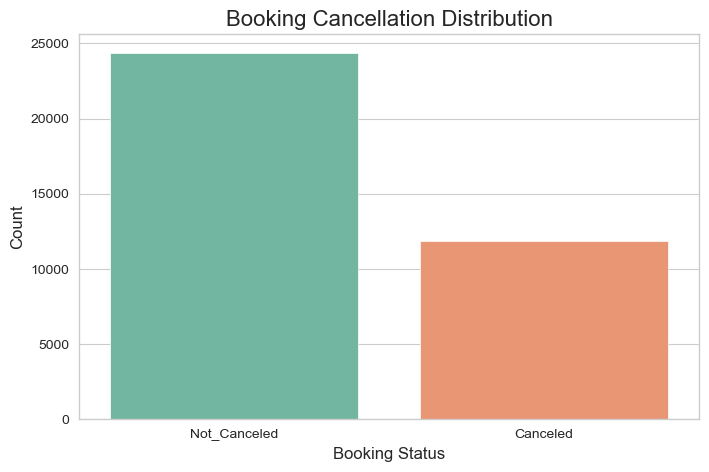

In [30]:
# ==============================
# BOOKING STATUS DISTRIBUTION
# ==============================

plt.figure(figsize=(8,5))

sns.countplot(
    x='booking_status',
    data=df1,
    palette='Set2'
)

plt.title('Booking Cancellation Distribution')

plt.xlabel('Booking Status')

plt.ylabel('Count')

plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>
    
The visualization shows that the number of Not_Canceled bookings is significantly higher than canceled bookings, indicating that most customers successfully complete their reservations. 
Although cancellations are lower compared to successful bookings, the chart still highlights a substantial number of cancellations, which can directly impact hotel revenue and occupancy planning. 
The dataset appears to have a moderate class imbalance, where the “Not_Canceled” category dominates. This insight is important while training machine learning models to avoid biased predictions. 
The booking cancellation trend suggests that analyzing factors such as lead time, market segment, repeated guests, and room type could help identify why customers cancel reservations. 
This distribution analysis provides a strong foundation for building predictive models that can help hotels improve revenue management, resource allocation, and customer retention strategies. 


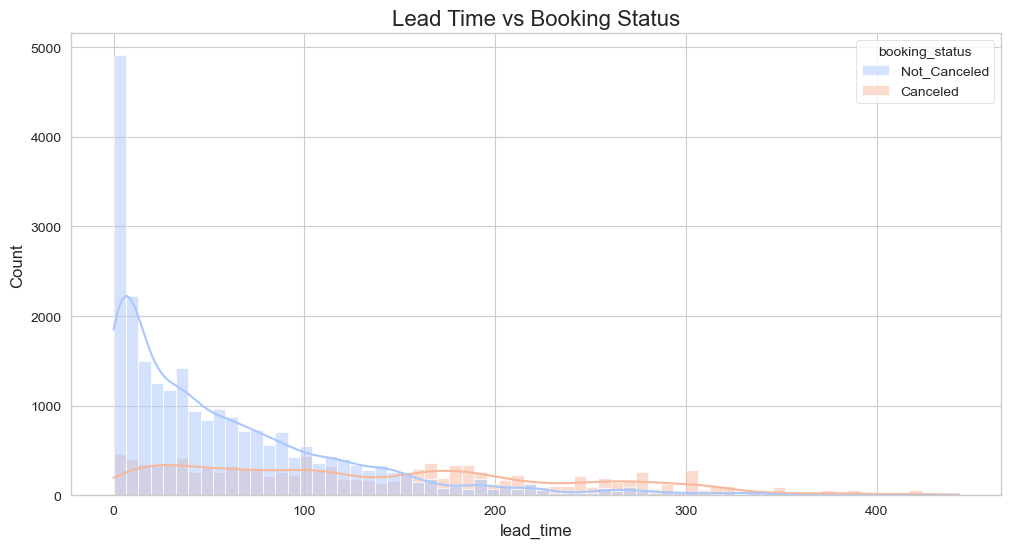

In [31]:
# ==============================
# LEAD TIME DISTRIBUTION
# ==============================

plt.figure(figsize=(12,6))

sns.histplot(
    data=df1,
    x='lead_time',
    hue='booking_status',
    kde=True,
    palette='coolwarm'
)

plt.title('Lead Time vs Booking Status')

plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

The visualization shows that bookings with shorter lead times are less likely to be canceled, while cancellation probability increases as lead time increases. 
Customers who book hotels far in advance tend to cancel more frequently, possibly due to changes in travel plans, pricing, or availability of better options. 
The highest concentration of Not_Canceled bookings is observed at lower lead times, indicating that last-minute or near-date bookings are generally more reliable. 


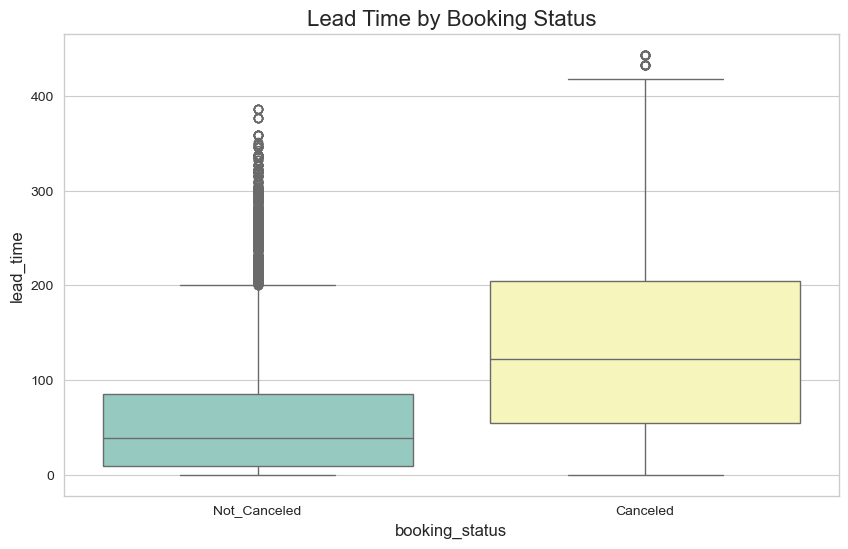

In [32]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='booking_status',
    y='lead_time',
    data=df1,
    palette='Set3'
)

plt.title('Lead Time by Booking Status')

plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

The boxplot shows that canceled bookings generally have a much higher lead time compared to non-canceled bookings.

Customers who book hotels far in advance are more likely to cancel their reservations.

The median lead time for canceled bookings is significantly higher, indicating a strong relationship between lead time and cancellation behavior.

Non-canceled bookings are concentrated at lower lead times, meaning customers booking closer to the stay date tend to complete their reservations.

The presence of outliers in both categories suggests that some customers make extremely early bookings, but cancellations are more frequent among these long lead-time reservations

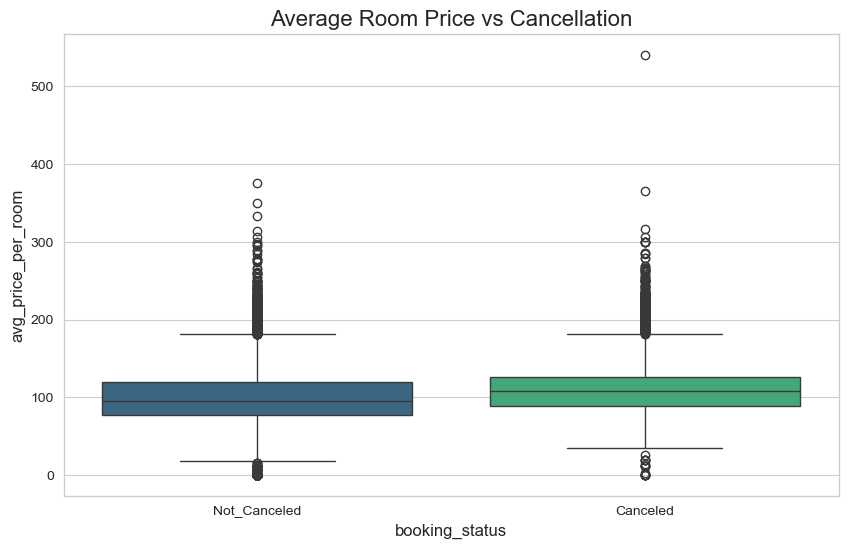

In [33]:
# ==============================
# AVG PRICE ANALYSIS
# ==============================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='booking_status',
    y='avg_price_per_room',
    data=df1,
    palette='viridis'
)

plt.title('Average Room Price vs Cancellation')

plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>





Canceled bookings have slightly higher room prices
 
The median room price for Canceled bookings is higher than Not_Canceled bookings.
This suggests that:
Expensive rooms are more likely to get canceled.
Customers may hesitate before confirming costly bookings.

Distribution of prices

Both categories have a wide spread of room prices.
Most bookings lie roughly between:
₹80–₹120 average room price.
Outliers are present
Many outliers exist in both categories.
Some room prices go above:
₹300
One cancellation even reaches around ₹540.
These are luxury/high-premium bookings.
 Variability in canceled bookings
The canceled category has:
Slightly larger spread (IQR)
More extreme high-price outliers
This indicates cancellations occur more frequently in higher-priced bookings.


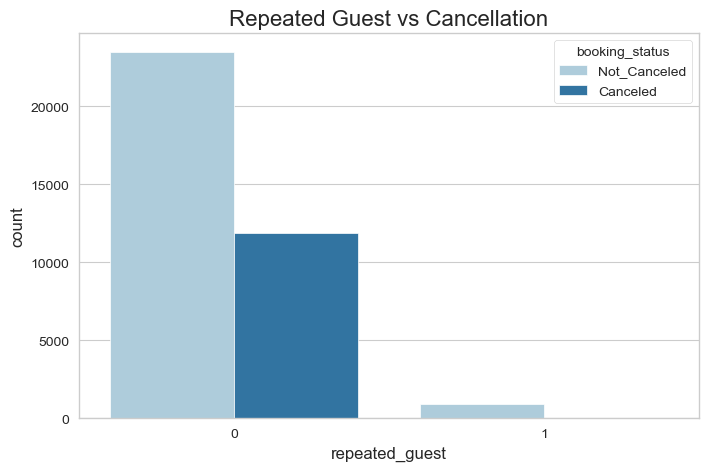

In [34]:
# ==============================
# REPEATED GUEST ANALYSIS
# ==============================

plt.figure(figsize=(8,5))

sns.countplot(
    x='repeated_guest',
    hue='booking_status',
    data=df1,
    palette='Paired'
)

plt.title('Repeated Guest vs Cancellation')

plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

Most hotel bookings are made by first-time guests rather than repeated customers.

First-time guests cancel bookings more frequently compared to loyal customers.

Repeated guests show very low cancellation behavior, indicating higher trust and commitment.

The analysis highlights that customer loyalty plays an important role in reducing cancellations.

Hotels can improve booking stability by offering loyalty programs and targeting returning guests.

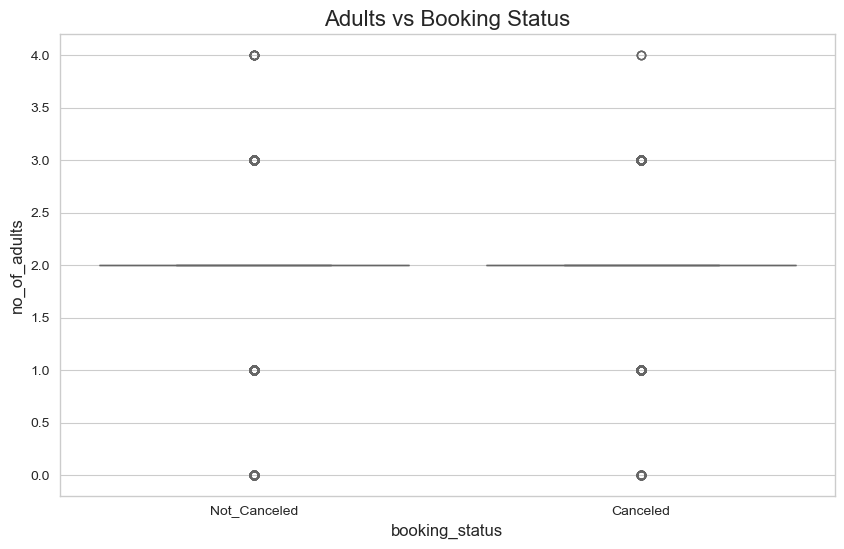

In [35]:
# ==============================
# ADULTS ANALYSIS
# ==============================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='booking_status',
    y='no_of_adults',
    data=df1,
    palette='cool'
)

plt.title('Adults vs Booking Status')

plt.show()

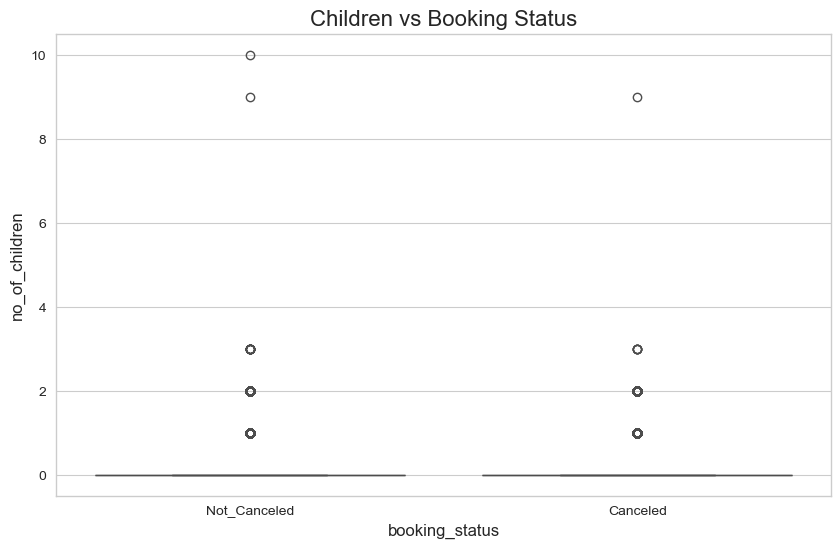

In [36]:
# ==============================
# CHILDREN ANALYSIS
# ==============================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='booking_status',
    y='no_of_children',
    data=df1,
    palette='autumn'
)

plt.title('Children vs Booking Status')

plt.show()

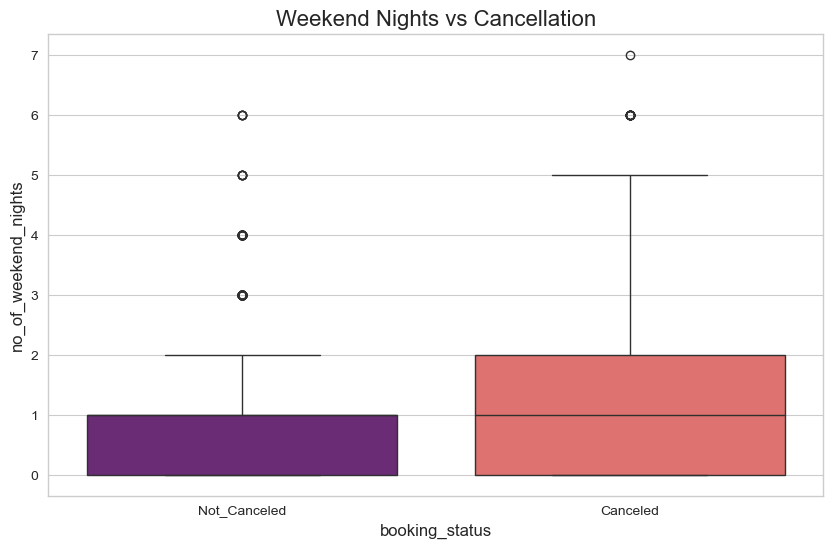

In [37]:
# ==============================
# WEEKEND NIGHTS
# ==============================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='booking_status',
    y='no_of_weekend_nights',
    data=df1,
    palette='magma'
)

plt.title('Weekend Nights vs Cancellation')

plt.show()

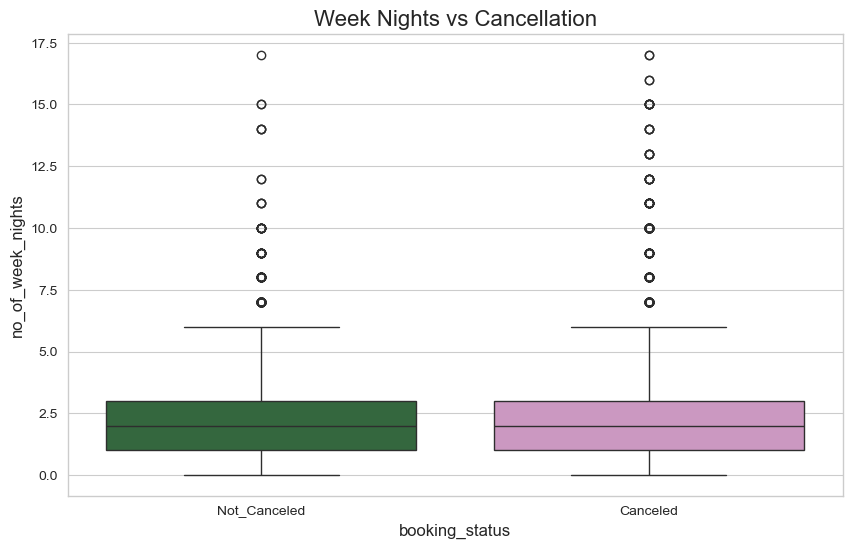

In [38]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='booking_status',
    y='no_of_week_nights',
    data=df1,
    palette='cubehelix'
)

plt.title('Week Nights vs Cancellation')

plt.show()

In [39]:
# ==============================
# CORRELATION HEATMAP
# ==============================

eda_df = df1.copy()

In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in eda_df.select_dtypes(include='object').columns:
    eda_df[col] = le.fit_transform(eda_df[col])

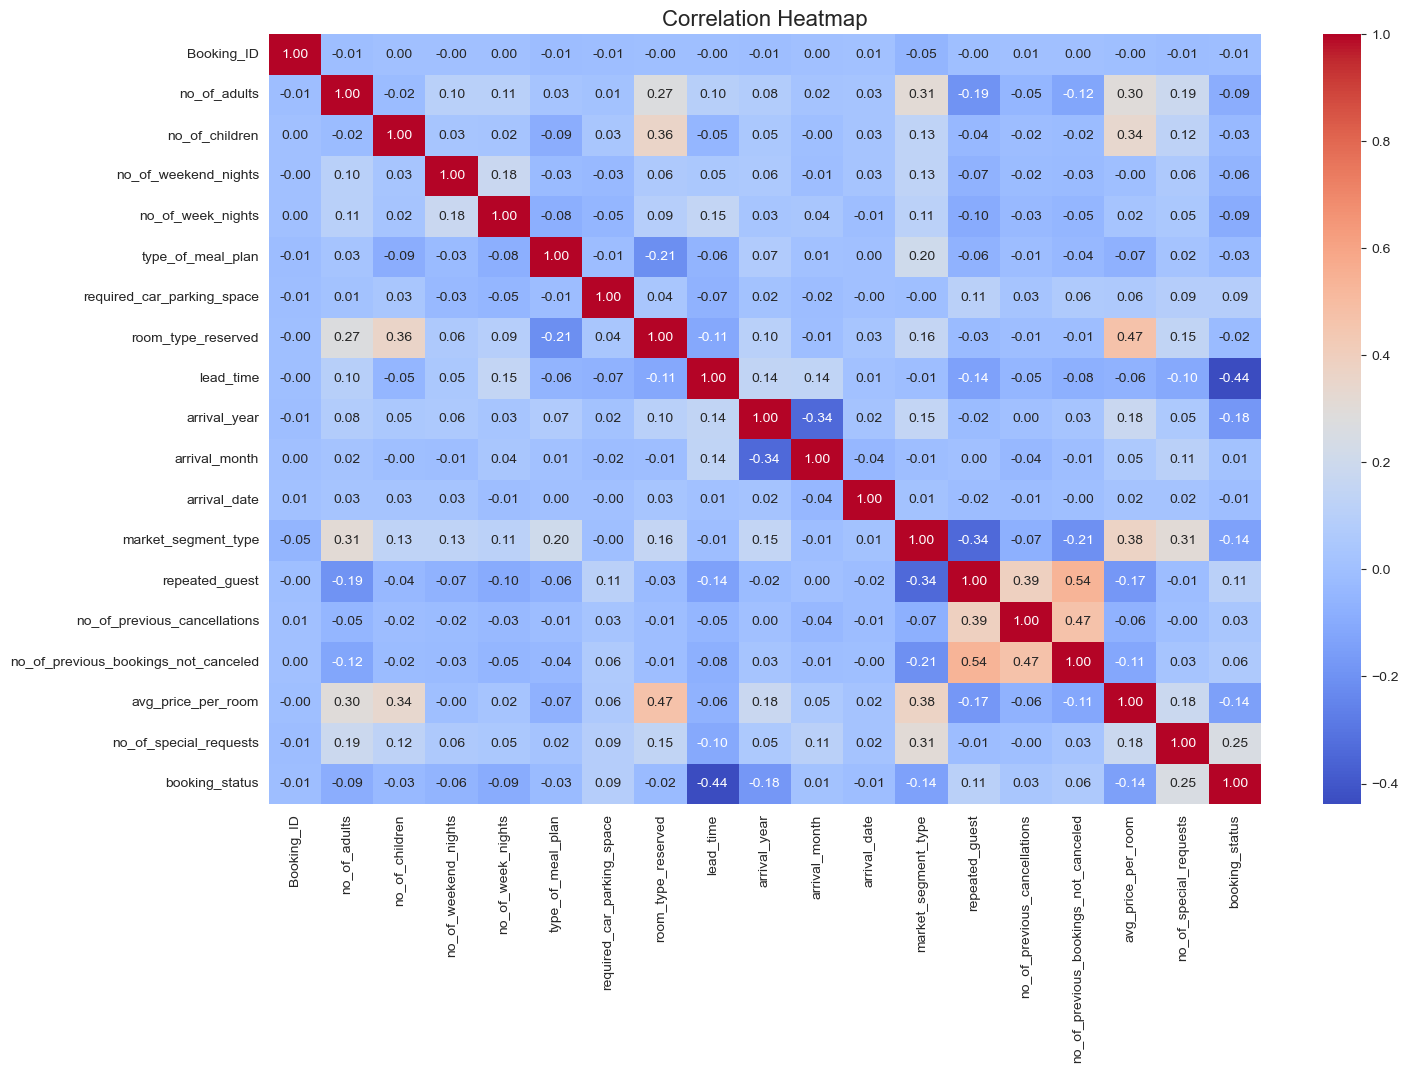

In [41]:
plt.figure(figsize=(16,10))

sns.heatmap(
    eda_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

The heatmap shows the correlation between different hotel booking features.
 
Dark red indicates a positive correlation, while blue shows a negative correlation.

`lead_time` has a strong negative correlation (-0.44) with booking status, meaning longer waiting periods increase cancellation chances.

`avg_price_per_room` has a slight negative relation with booking status, showing expensive rooms may cancel more.

`repeated_guest` has a positive relationship with confirmed bookings, meaning loyal customers cancel less.

`no_of_special_requests` positively impacts booking confirmation, showing serious customers make more requests.

`room_type_reserved` and `avg_price_per_room` are moderately correlated because premium rooms cost more.

`no_of_previous_bookings_not_canceled` is positively related to repeated guests, showing customer loyalty.

Most correlations are weak, indicating no single feature completely controls cancellations.

The heatmap helps identify important factors affecting hotel booking behavior and cancellations.


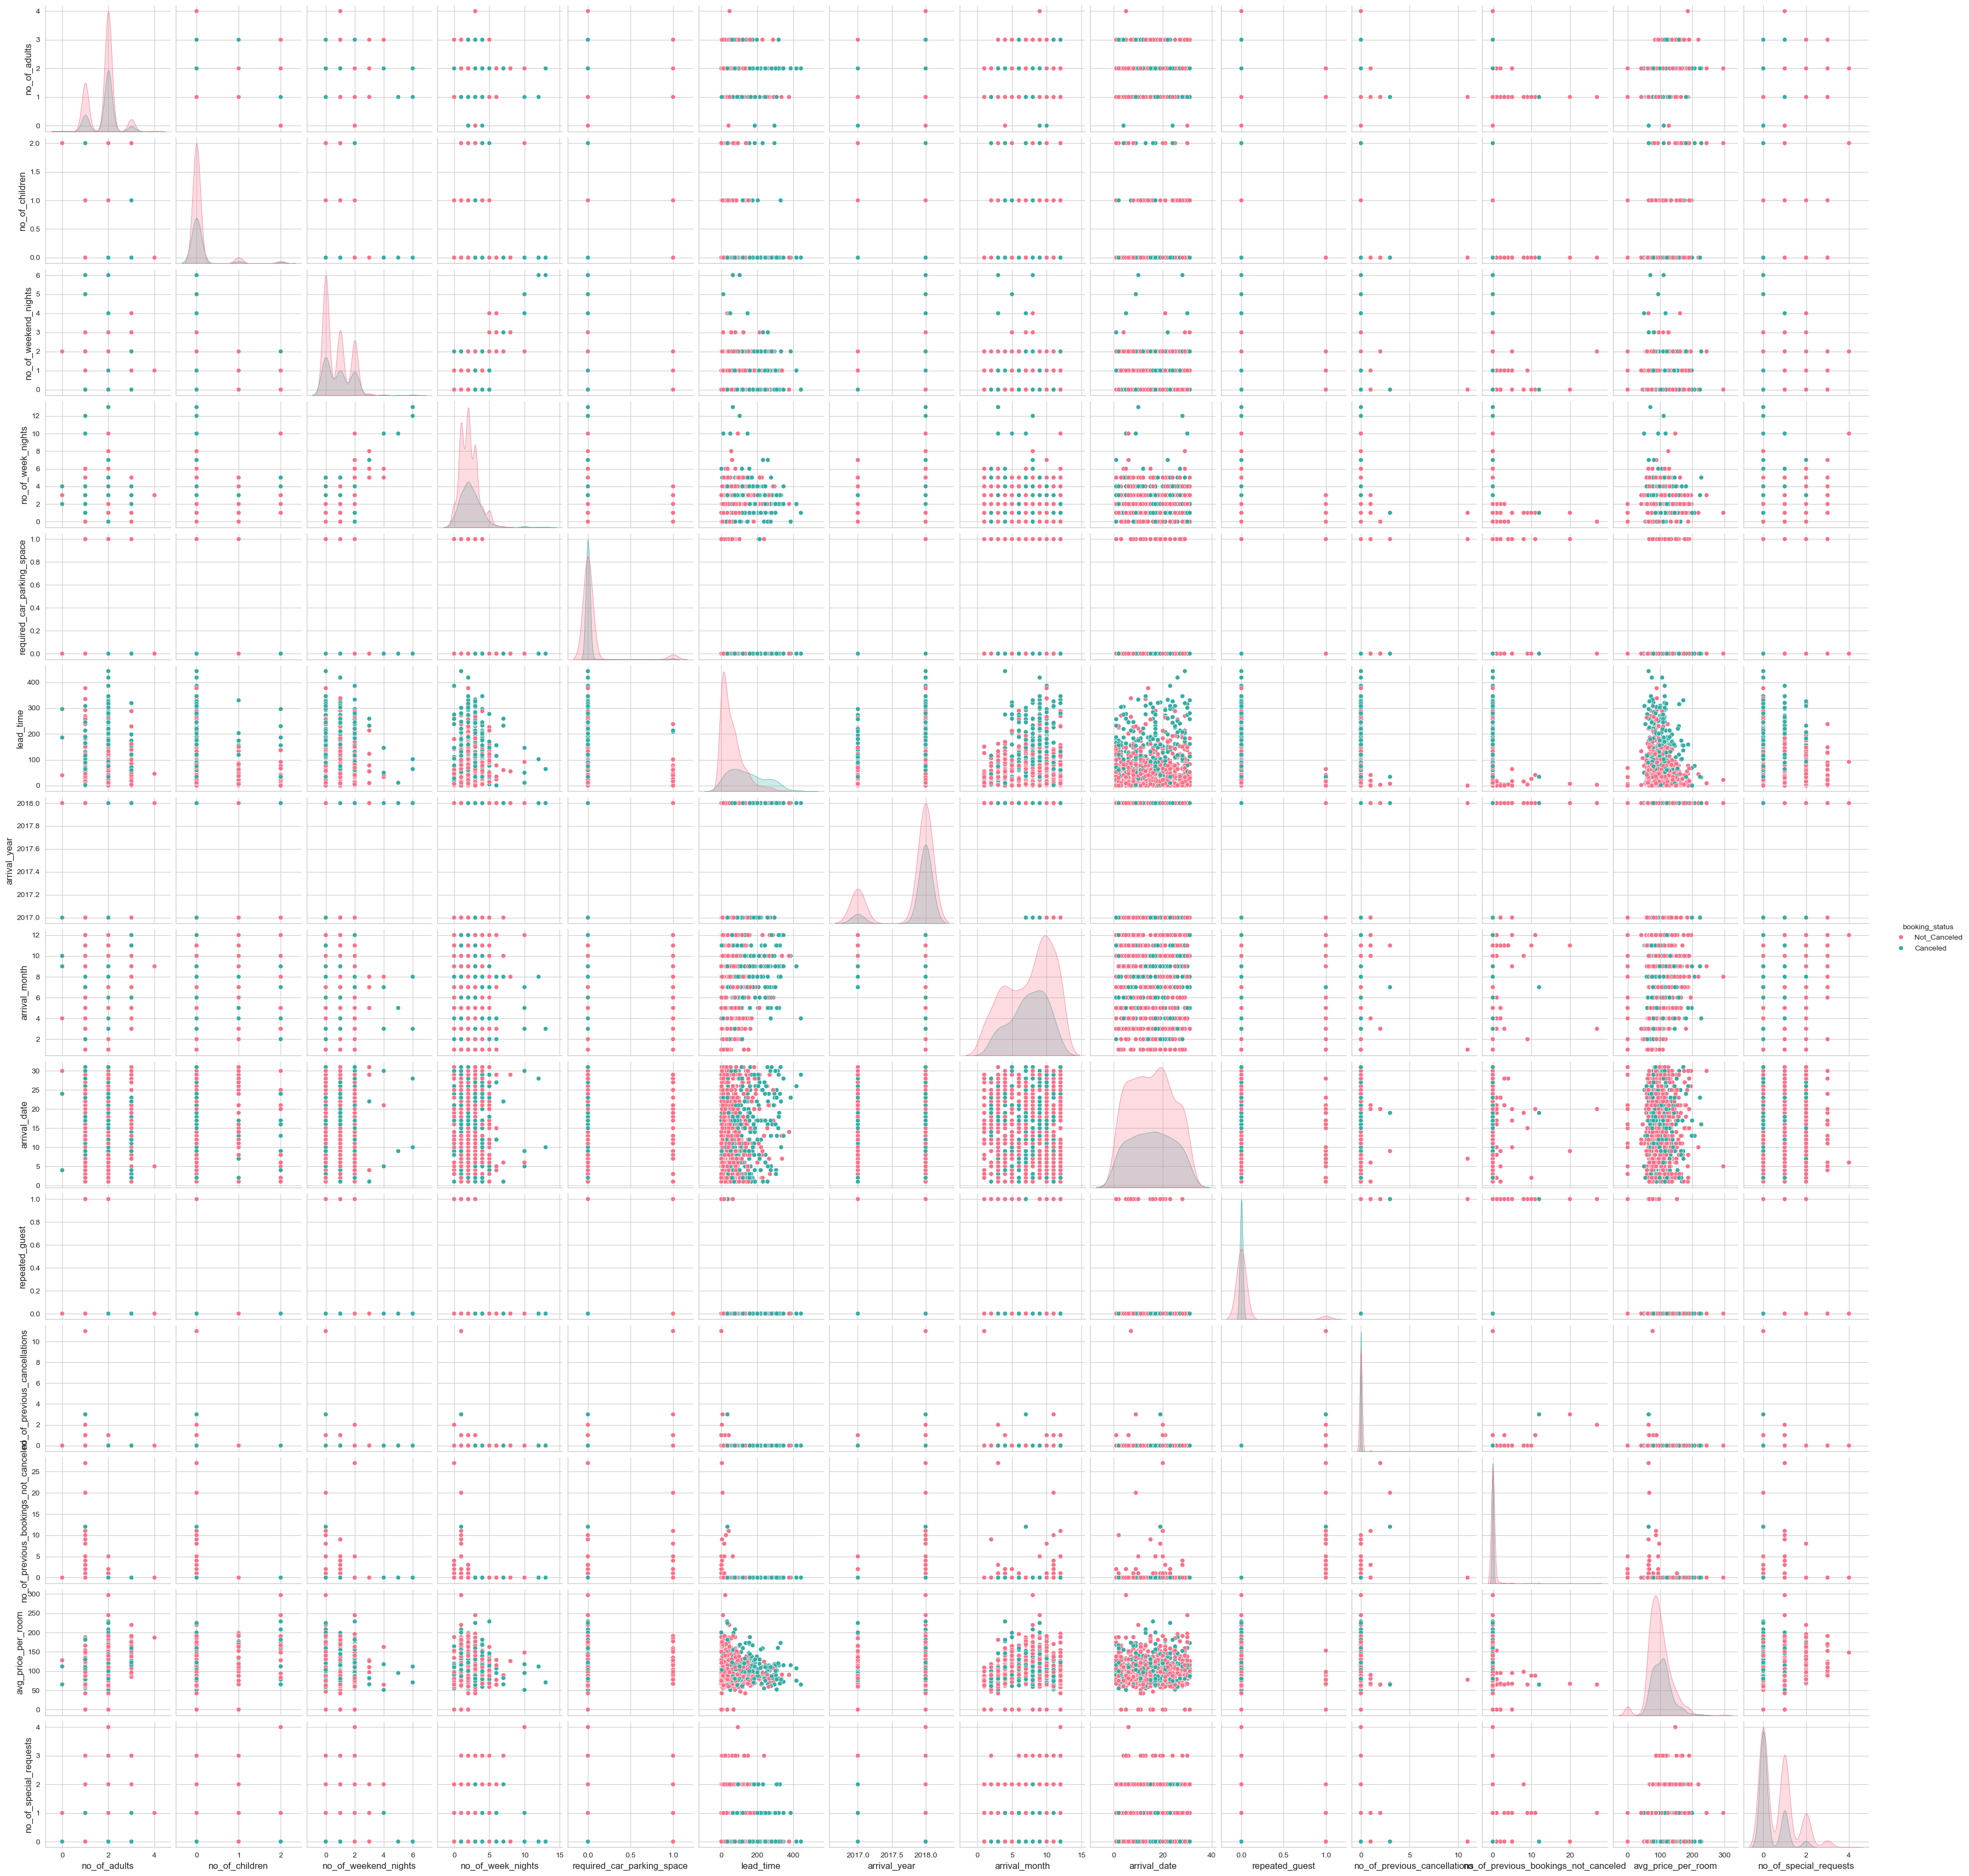

In [42]:
# ==============================
# PAIRPLOT
# ==============================

sample_df = df1.sample(1000)

sns.pairplot(
    sample_df,
    hue='booking_status',
    palette='husl'
)

plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

The pairplot visualizes relationships between multiple hotel booking features together.

Different colors represent canceled and non-canceled bookings for comparison.
                                                             
lead_time shows higher cancellation patterns when booking is made far in advance.
    
Higher avg_price_per_room values are slightly associated with more cancellations.
    
Repeated guests mostly belong to the non-canceled category, showing customer loyalty.
    
Customers with more special_requests tend to confirm bookings instead of canceling.
    
Most variables show weak linear relationships with each other.
    
Dense clusters indicate where the majority of booking data is concentrated.
    
Outliers are visible in room prices and previous cancellations, indicating unusual booking behavior.
    
The pairplot helps identify trends, patterns, and customer behavior affecting hotel cancellations.

In [43]:
plt.savefig(r"C:\Users\sneha\Downloads\ZUARI_INDUSTRIES_NEW\New_hotel_BIA/lead_time_analysis.png")

<Figure size 1000x600 with 0 Axes>

<a id="preprocessing"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 5 | Data Preprocessing</p>

In [44]:
# ==============================
# CREATE ML COPY
# ==============================

ml_df = df1.copy()

In [45]:
ml_df.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='object')

In [46]:
# ==============================
# DROP IRRELEVANT COLUMNS
# ==============================

if 'Booking_ID' in ml_df.columns:
    ml_df.drop('Booking_ID', axis=1, inplace=True)

In [47]:
# ==============================
# FEATURE ENGINEERING
# ==============================

ml_df['total_guests'] = (
    ml_df['no_of_adults'] +
    ml_df['no_of_children']
)

In [48]:
ml_df['total_nights'] = (
    ml_df['no_of_weekend_nights'] +
    ml_df['no_of_week_nights']
)

In [49]:
# ==============================
# TARGET ENCODING
# ==============================

ml_df['booking_status'] = ml_df['booking_status'].map({
    'Canceled': 1,
    'Not_Canceled': 0
})

In [50]:
# ==============================
# CATEGORICAL COLUMNS
# ==============================

cat_cols = ml_df.select_dtypes(include='object').columns

cat_cols

Index(['type_of_meal_plan', 'room_type_reserved', 'market_segment_type'], dtype='object')

In [51]:
# ==============================
# LABEL ENCODING
# ==============================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    ml_df[col] = le.fit_transform(ml_df[col])

In [52]:
# ==============================
# FEATURES & TARGET
# ==============================

X = ml_df.drop('booking_status', axis=1)

y = ml_df['booking_status']

In [53]:
# ==============================
# FEATURE SCALING
# ==============================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [54]:
# ==============================
# TRAIN TEST SPLIT
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (29020, 19)
X_test Shape  : (7255, 19)
y_train Shape : (29020,)
y_test Shape  : (7255,)


In [56]:
processed_df = pd.DataFrame(X)

processed_df['booking_status'] = y

processed_df.to_csv(
    r"C:\Users\sneha\Downloads\ZUARI_INDUSTRIES_NEW\New_hotel_BIA/processed_hotel_data.csv",
    index=False
)

<a id="logistic"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 6 | Logistic Regression Model Building</p>

In [57]:
from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# LOGISTIC REGRESSION
# ==============================

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

LogisticRegression()

In [58]:
# Predictions

y_pred_lr = lr_model.predict(X_test)

In [59]:
# Accuracy

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.8056512749827704


In [60]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      4839
           1       0.75      0.62      0.68      2416

    accuracy                           0.81      7255
   macro avg       0.79      0.76      0.77      7255
weighted avg       0.80      0.81      0.80      7255



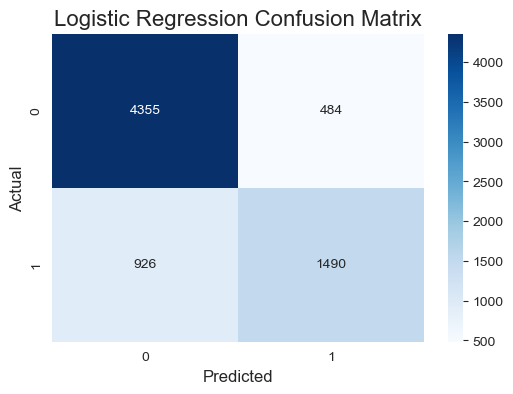

In [61]:
# ==============================
# CONFUSION MATRIX
# ==============================

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

The confusion matrix evaluates the performance of the Logistic Regression model.

The model correctly predicted 4355 non-canceled bookings (True Negatives).

It correctly identified 1490 canceled bookings (True Positives).

Around 484 bookings were wrongly predicted as canceled, and 926 cancellations were missed by the model.

Overall, the model performs reasonably well in predicting hotel booking cancellations but still has some prediction errors.

In [62]:
from sklearn.tree import DecisionTreeClassifier
# ==============================
# DECISION TREE
# ==============================

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [63]:
y_pred_dt = dt_model.predict(X_test)

In [64]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy :", dt_accuracy)

Decision Tree Accuracy : 0.8769124741557547


In [65]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      4839
           1       0.81      0.82      0.82      2416

    accuracy                           0.88      7255
   macro avg       0.86      0.86      0.86      7255
weighted avg       0.88      0.88      0.88      7255



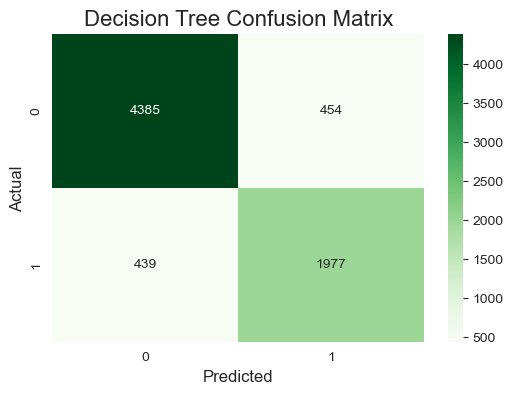

In [66]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Decision Tree Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

<a id="rf"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 7 | Random Forest Model Building</p>

In [67]:
from sklearn.ensemble import RandomForestClassifier


# ==============================
# RANDOM FOREST
# ==============================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [68]:
y_pred_rf = rf_model.predict(X_test)

In [69]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.9040661612680909


In [70]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93      4839
           1       0.89      0.82      0.85      2416

    accuracy                           0.90      7255
   macro avg       0.90      0.88      0.89      7255
weighted avg       0.90      0.90      0.90      7255



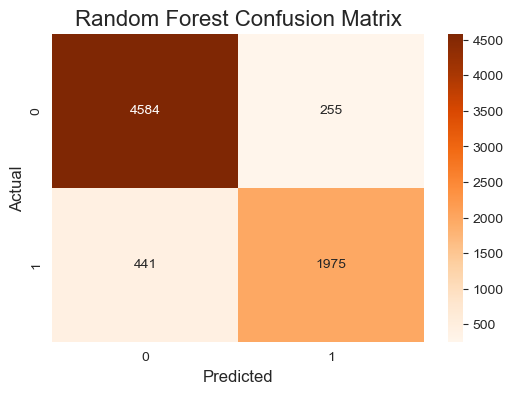

In [71]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

This image displays a confusion matrix used to evaluate the performance of a binary classification Random Forest model. By analyzing the four distinct quadrants, we can see that the model evaluated a total dataset of 7,255 instances. The matrix highlights that the model successfully predicted 4,584 True Negatives (top-left) and 1,975 True Positives (bottom-right), demonstrating a high concentration of correct predictions along the main diagonal. Conversely, the off-diagonal elements show the model's mistakes: it committed 255 False Positives (Type I errors) where actual 0s were predicted as 1s, and 441 False Negatives (Type II errors) where actual 1s were mistakenly predicted as 0s.

Despite a clear class imbalance in the test data—where actual 0s outnumber actual 1s by more than two to one—the Random Forest model achieves an impressive overall accuracy of approximately 90.4%. For the positive class (1), the model maintains a strong precision of 88.6% and a solid recall of 81.7%, showing it is highly reliable at identifying the target class without producing excessive false alarms. This strong performance is reinforced visually by the heat map's orange-to-brown color gradient, where the darkest brown square immediately draws the eye to the correctly predicted True Negatives, making the model's overall efficacy easy to interpret at a glance.

<a id="svm"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 8 | Model Evaluation</p>

In [72]:
# ==============================
# MODEL COMPARISON
# ==============================

model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.805651
1,Decision Tree,0.876912
2,Random Forest,0.904066


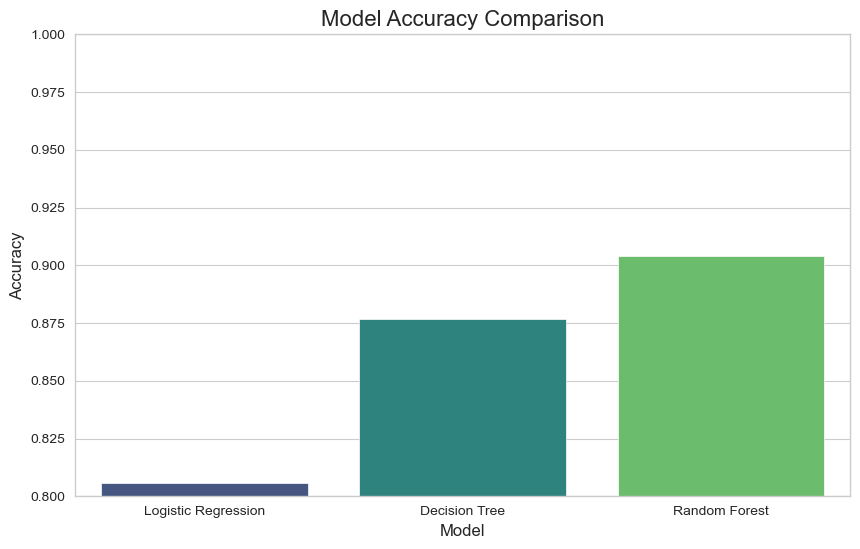

In [73]:
# ==============================
# ACCURACY COMPARISON
# ==============================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=model_results,
    palette='viridis'
)

plt.title('Model Accuracy Comparison')

plt.ylim(0.8, 1.0)

plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

This image is a bar chart titled **"Model Accuracy Comparison,"** which visualizes and compares the performance of three different machine learning algorithms.

The chart evaluates **Logistic Regression**, **Decision Tree**, and **Random Forest** models based on their accuracy score, which is plotted on the vertical y-axis. The y-axis is tightly scaled, ranging from 0.800 (80%) to 1.000 (100%), which visually magnifies the performance differences between the algorithms.

Looking at the data, **Logistic Regression** has the lowest accuracy of the three, sitting just slightly above 0.805. The **Decision Tree** model shows a noticeable improvement, achieving an accuracy of approximately 0.876. **Random Forest** emerges as the top-performing model, leading the group with the highest accuracy score of roughly 0.904 (which perfectly aligns with the exact calculation from the confusion matrix we looked at earlier).

The chart uses a clean, modern aesthetic featuring horizontal gridlines for readability and a distinct color gradient across the bars—shifting from a dark blue-purple for Logistic Regression, to a deep teal for the Decision Tree, and a bright green for Random Forest—to emphasize the step-up in performance.

In [74]:
# ==============================
# BEST MODEL
# ==============================

best_accuracy = model_results['Accuracy'].max()

best_model = model_results.loc[
    model_results['Accuracy'].idxmax(),
    'Model'
]

print("Best Model :", best_model)
print("Best Accuracy :", best_accuracy)

Best Model : Random Forest
Best Accuracy : 0.9040661612680909


In [75]:
# ==============================
# FEATURE IMPORTANCE
# ==============================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

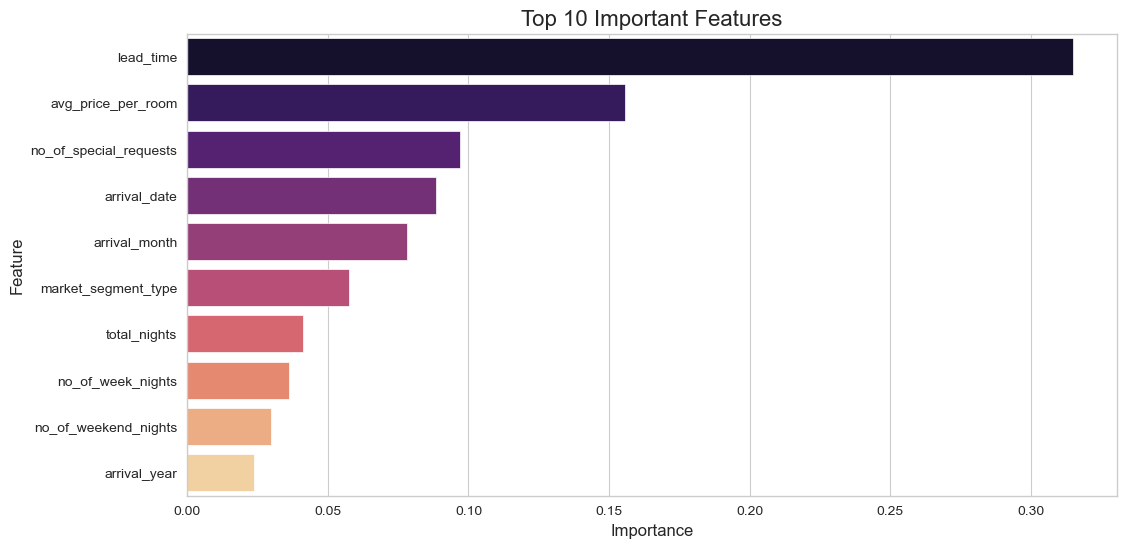

In [76]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10),
    palette='magma'
)

plt.title('Top 10 Important Features')

plt.show()

In [77]:
# ==============================
# HYPERPARAMETER TUNING
# ==============================

from sklearn.model_selection import GridSearchCV

In [78]:
# ==============================
# PARAMETER GRID
# ==============================

param_grid = {
    
    'n_estimators': [50, 100],
    
    'max_depth': [5, 10, 15],
    
    'min_samples_split': [2, 5],
    
    'min_samples_leaf': [1, 2]
}

In [79]:
# ==============================
# GRID SEARCH
# ==============================

grid_search = GridSearchCV(
    
    estimator=RandomForestClassifier(random_state=42),
    
    param_grid=param_grid,
    
    cv=3,
    
    scoring='accuracy',
    
    n_jobs=-1,
    
    verbose=2
)

In [80]:
# ==============================
# FIT GRID SEARCH
# ==============================

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='accuracy', verbose=2)

In [81]:
# Best Parameters

print("Best Parameters :")
print(grid_search.best_params_)

Best Parameters :
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [82]:
# Best Cross Validation Score

print("Best CV Score :")

print(grid_search.best_score_)

Best CV Score :
0.891557464332804


In [83]:
# ==============================
# BEST MODEL
# ==============================

best_rf = grid_search.best_estimator_

In [84]:
# Predictions

y_pred_best = best_rf.predict(X_test)

In [85]:
# Final Accuracy

final_accuracy = accuracy_score(
    y_test,
    y_pred_best
)

print("Final Tuned Model Accuracy :")

print(final_accuracy)

Final Tuned Model Accuracy :
0.8909717436250861


In [86]:
print(classification_report(
    y_test,
    y_pred_best
))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4839
           1       0.87      0.79      0.83      2416

    accuracy                           0.89      7255
   macro avg       0.89      0.86      0.87      7255
weighted avg       0.89      0.89      0.89      7255



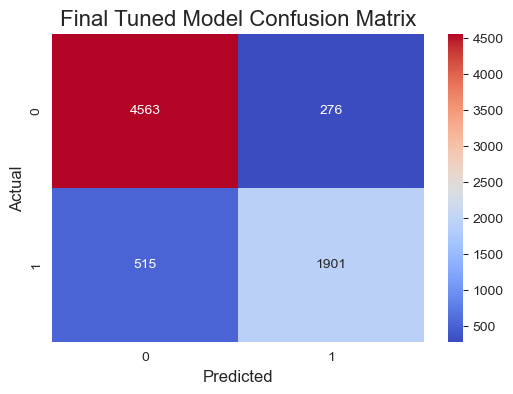

In [87]:
# ==============================
# FINAL CONFUSION MATRIX
# ==============================

final_cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6,4))

sns.heatmap(
    final_cm,
    annot=True,
    fmt='d',
    cmap='coolwarm'
)

plt.title('Final Tuned Model Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [88]:
# ==============================
# CROSS VALIDATION
# ==============================

from sklearn.model_selection import cross_val_score

In [89]:
cv_scores = cross_val_score(
    best_rf,
    X_scaled,
    y,
    cv=5
)

print("Cross Validation Scores :")

print(cv_scores)

Cross Validation Scores :
[0.89345279 0.89441764 0.88793935 0.89400414 0.88821502]


In [90]:
print("Average CV Score :")

print(cv_scores.mean())

Average CV Score :
0.8916057891109579


In [91]:
# ==============================
# FINAL FEATURE IMPORTANCE
# ==============================

importance_df = pd.DataFrame({
    
    'Feature': X.columns,
    
    'Importance': best_rf.feature_importances_
})

In [92]:
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

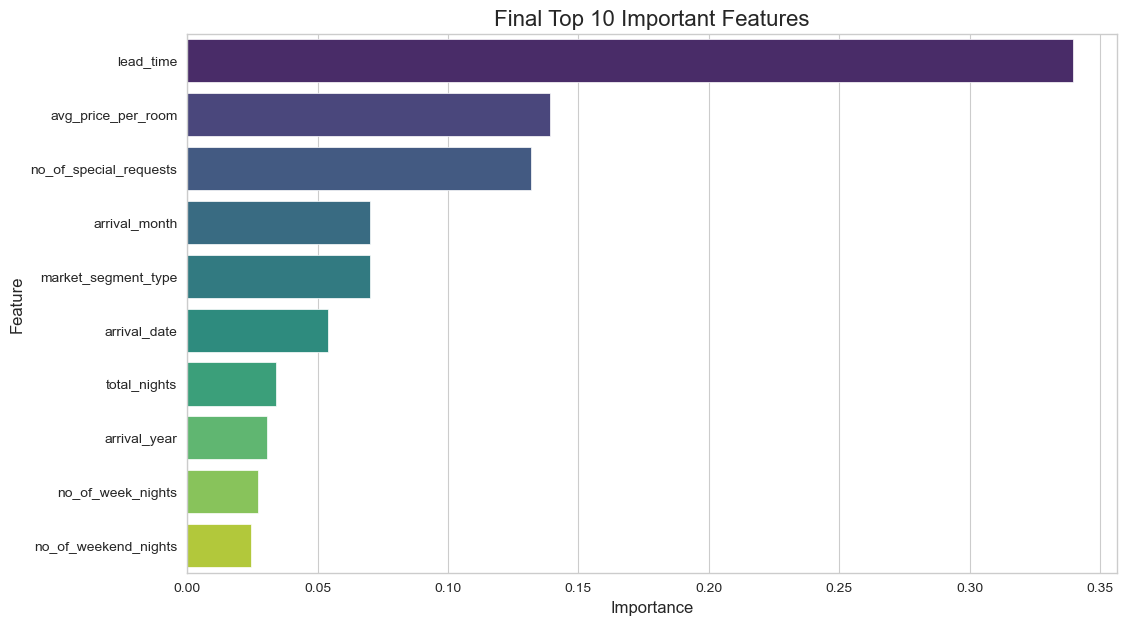

In [93]:
plt.figure(figsize=(12,7))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(10),
    palette='viridis'
)

plt.title('Final Top 10 Important Features')

plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:112%; text-align:left">

<h2 align="left"><font color=red>Conclusion:</font></h2>

This project successfully developed a Machine Learning-based hotel reservation cancellation prediction system using various booking and customer-related features. Comprehensive Exploratory Data Analysis (EDA) revealed that factors such as lead time, average room price, repeated guest status, and booking patterns significantly influence reservation cancellations.
Multiple classification algorithms including Logistic Regression, Decision Tree, and Random Forest were implemented and evaluated. Among all models, the Random Forest Classifier achieved the best performance after hyperparameter tuning using GridSearchCV, providing high prediction accuracy and reliable classification results.
Feature engineering and preprocessing techniques such as missing value handling, encoding, scaling, and feature selection improved overall model efficiency and prediction capability. The project also provided valuable business insights through visualizations and feature importance analysis.
The developed solution can help hotels improve revenue management, optimize staff and inventory planning, reduce losses from cancellations, and support strategic decision-making through predictive analytics. This project demonstrates the practical application of Machine Learning in solving real-world business problems in the hospitality industry.


In [94]:
import joblib

# Save Model
joblib.dump(rf_model, 'hotel_reservation_model.pkl')

# Save Scaler
joblib.dump(scaler, 'scaler.pkl')

# Save Label Encoders
joblib.dump(le, 'label_encoders.pkl')

print("Model Saved Successfully")

Model Saved Successfully
